<center>

# Analytical calculations for Incoherent test

#### Author: Daniel Lomholt Christensen

</center>

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import mcstasscript as ms
import pyFAI as pf

#### Analytical form factor of sphere solution


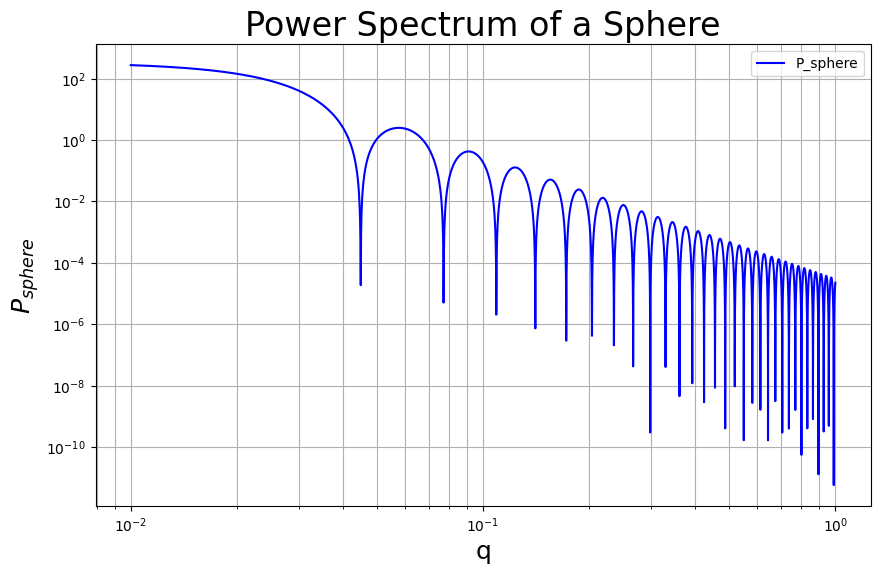

In [160]:
def P_sphere(q, R):
    res = 3*(np.sin(q*R) - q*R*np.cos(q*R) )/ (q*R)**3
    res = res**2
    return res

def n_measured(flux, A, dist, solid, sigma_att, phi,delta_rho, V, S, q,R):
    return flux*A*dist*solid/4/np.pi*sigma_att*phi*delta_rho**2*V*S*P_sphere(q,R)
flux = 1e7 # n/s/cm^2
a = 1 # cm^2
dist = 1 # cm
solid = 10_000/1000_000 # cm^2/cm^2
sigma_att = np.exp(-0.5*dist*10) # 
delta_rho = 5**2 #
phi = 1e-2 #
V = 1
S = 1
q = np.linspace(0.01, 1, 10000)
R = 100

anal = n_measured(flux, a, dist, solid, sigma_att, phi,delta_rho, V, S, q,R)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(q, anal, label='P_sphere', color='blue')
ax.set(xscale="log", yscale="log")
ax.set_title("Power Spectrum of a Sphere", fontsize=24)
ax.set_xlabel("q", fontsize=18)
ax.set_ylabel(r'$P_{sphere}$', fontsize=18)
ax.legend()
ax.grid(True, which='both')



In [161]:
# Load in the sans data
data = ms.load_data("../data/sans")
data = data[2] # And restrict ourselves to the last monitor

In [162]:
# detector = pf.detectors.Detector(100e-5, 100e-5)
detector = pf.detector_factory("detector")
detector.set_pixel1(1/1000)
detector.set_pixel2(1/1000)

# Set the azimuthal integrator
# ai = pf.AzimuthalIntegrator(dist=1, detector=detector)


ai = pf.integrator.azimuthal.AzimuthalIntegrator(dist=5, detector=detector)
wavelength = 1/np.sqrt(5)/0.11056
ai.set_wavelength(4*1e-10)
ai.poni1  = 0.5
ai.poni2 = 0.5
two_theta, I = ai.integrate1d(data.Intensity, 100, unit="2th_deg") 
result = ai.integrate2d(data.Intensity, 100)

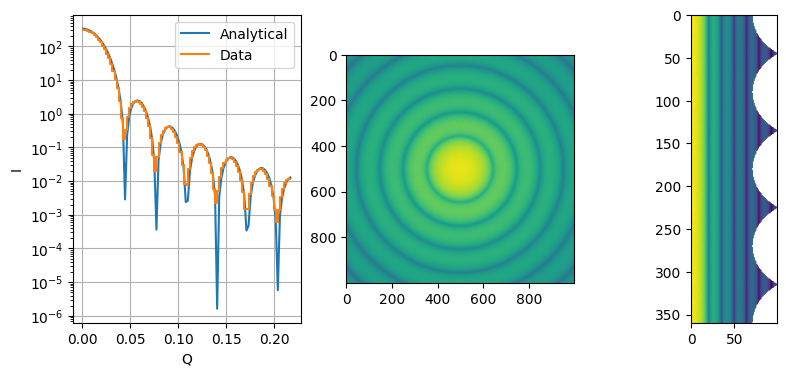

In [163]:
fig, ax = plt.subplots(ncols=3, figsize=(10,4))
q = np.sin((two_theta)*np.pi/180/2)*4*np.pi/wavelength


ax[0].set(yscale="log")

ax[0].plot(q,n_measured(flux, a, dist, solid, sigma_att, phi,delta_rho, V, S, q,R), label="Analytical")
# q = np.insert(q,0,1e-3)[:-1]
ax[0].step(q, I,label="Data")

# Set legends and labels
ax[0].legend()
ax[0].grid(True, which='major')
ax[0].set(xlabel="Q", ylabel="I")

ax[1].imshow(data.Intensity, norm="log")

ax[2].imshow(result[0], norm="log")
